# 04: Cepstral Modeling, Linear Filterbanks & Vocal Tract Resonances

## 1. Research Scope & Objectives
This notebook analyzes cepstral representations (MFCC, LFCC, CQCC), vocal tract all-pole filter modeling via Linear Predictive Coding (LPC), and glottal inverse filtering residuals.

### Mathematical Formulations
Linear Frequency Cepstral Coefficients (LFCC):
$$\text{LFCC}_{60} = [\text{Static}_{20}, \Delta_{20}, \Delta\Delta_{20}]$$
LPC Prediction Residual:
$$e[n] = x[n] - \sum_{k=1}^P a_k x[n-k]$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa, scipy.fftpack as fft, scipy.signal
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)

## 2. Linear Filterbank Construction vs Mel Filterbank
LFCC utilizes linearly spaced triangular filterbanks to preserve high-frequency forensic information.

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


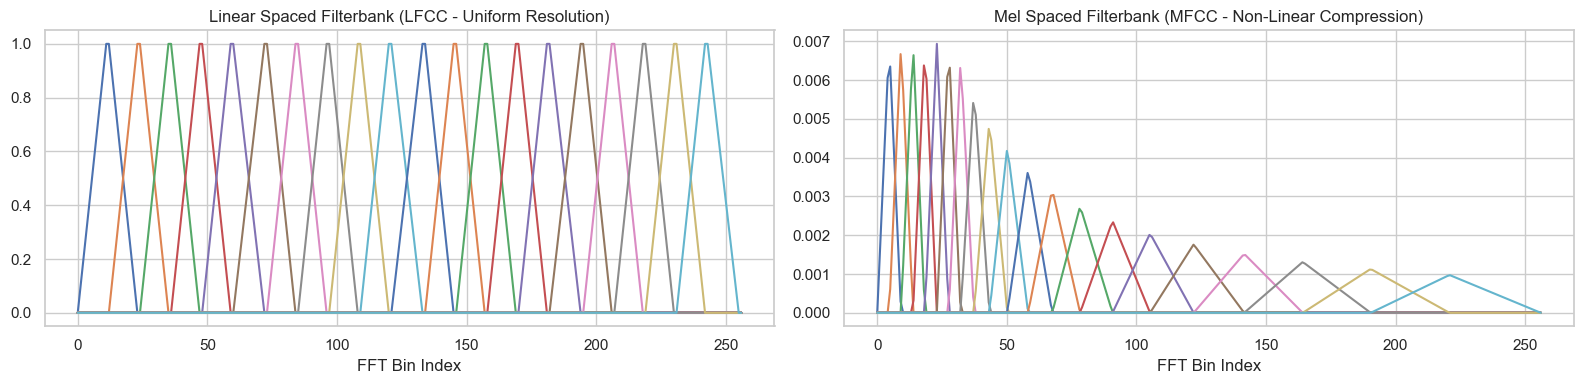

In [2]:
def create_linear_filterbank(sr=16000, n_fft=512, n_filters=20):
    n_bins = n_fft // 2 + 1
    fbank = np.zeros((n_filters, n_bins))
    pts = np.linspace(0, n_bins - 1, n_filters + 2, dtype=int)
    for i in range(n_filters):
        fbank[i, pts[i]:pts[i+1]] = np.linspace(0, 1, pts[i+1] - pts[i])
        fbank[i, pts[i+1]:pts[i+2]] = np.linspace(1, 0, pts[i+2] - pts[i+1])
    return fbank

lin_fb = create_linear_filterbank(16000, 512, 20)
mel_fb = librosa.filters.mel(sr=16000, n_fft=512, n_mels=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(lin_fb.T)
axes[0].set_title("Linear Spaced Filterbank (LFCC - Uniform Resolution)")
axes[0].set_xlabel("FFT Bin Index")

axes[1].plot(mel_fb.T)
axes[1].set_title("Mel Spaced Filterbank (MFCC - Non-Linear Compression)")
axes[1].set_xlabel("FFT Bin Index")
plt.tight_layout()
plt.show()

## 3. 60-Dimensional LFCC Feature Extraction
We extract static, velocity (Delta), and acceleration (Delta-Delta) cepstral coefficients.

In [3]:
def extract_lfcc_60(y, sr=16000, n_fft=512, hop_length=256, n_filters=20):
    frames = librosa.util.frame(y, frame_length=n_fft, hop_length=hop_length)
    windowed = frames * np.hanning(n_fft)[:, None]
    spectrum = np.abs(np.fft.rfft(windowed, n=n_fft, axis=0))**2
    fbank = create_linear_filterbank(sr, n_fft, n_filters)
    energy = np.dot(fbank, spectrum)
    log_energy = np.log(np.maximum(energy, 1e-8))
    static_lfcc = fft.dct(log_energy, type=2, axis=0, norm="ortho")[:n_filters]
    delta = librosa.feature.delta(static_lfcc, order=1)
    delta2 = librosa.feature.delta(static_lfcc, order=2)
    return np.vstack([static_lfcc, delta, delta2])

sample_bon = df[df.key == "bonafide"].iloc[0]["file_path"]
sample_spoof = df[df.key == "spoof"].iloc[0]["file_path"]

y_b, sr = sf.read(sample_bon)
y_s, _ = sf.read(sample_spoof)

lfcc_b = extract_lfcc_60(y_b, sr)
lfcc_s = extract_lfcc_60(y_s, sr)

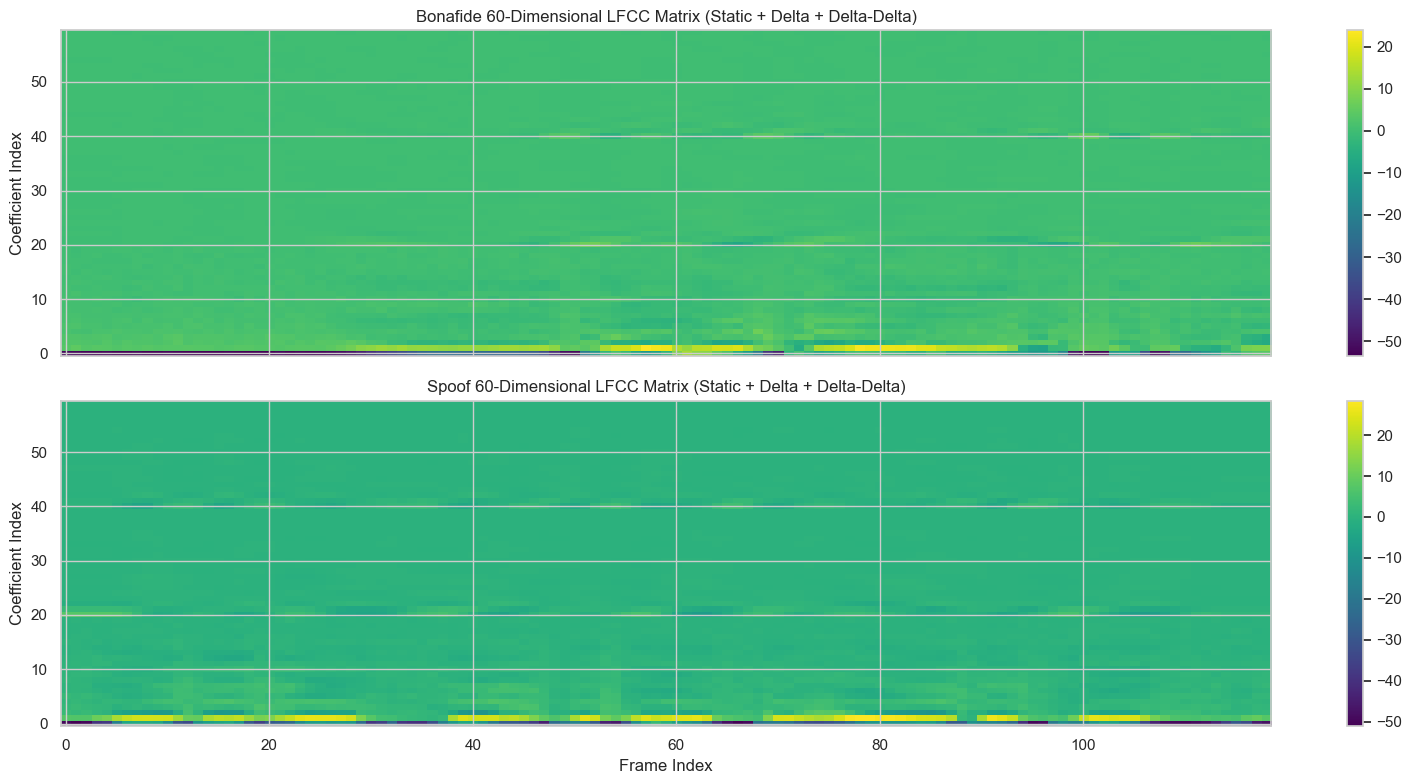

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
im1 = axes[0].imshow(lfcc_b, aspect="auto", origin="lower", cmap="viridis")
axes[0].set_title("Bonafide 60-Dimensional LFCC Matrix (Static + Delta + Delta-Delta)")
axes[0].set_ylabel("Coefficient Index")
fig.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(lfcc_s, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title("Spoof 60-Dimensional LFCC Matrix (Static + Delta + Delta-Delta)")
axes[1].set_ylabel("Coefficient Index")
axes[1].set_xlabel("Frame Index")
fig.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Constant Q-Transform (CQT) & Octave Geometric Harmonics

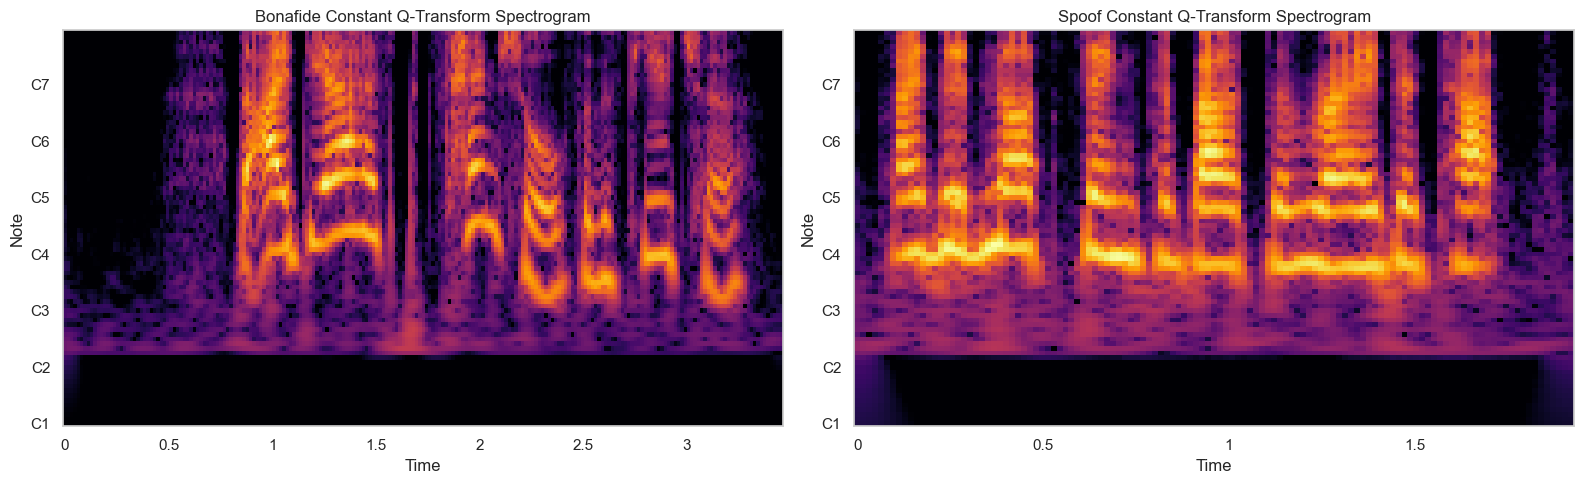

In [5]:
cqt_b = librosa.amplitude_to_db(np.abs(librosa.cqt(y_b, sr=sr, hop_length=256, n_bins=84, bins_per_octave=12)), ref=np.max)
cqt_s = librosa.amplitude_to_db(np.abs(librosa.cqt(y_s, sr=sr, hop_length=256, n_bins=84, bins_per_octave=12)), ref=np.max)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
librosa.display.specshow(cqt_b, sr=sr, hop_length=256, x_axis="time", y_axis="cqt_note", ax=axes[0], cmap="inferno")
axes[0].set_title("Bonafide Constant Q-Transform Spectrogram")
librosa.display.specshow(cqt_s, sr=sr, hop_length=256, x_axis="time", y_axis="cqt_note", ax=axes[1], cmap="inferno")
axes[1].set_title("Spoof Constant Q-Transform Spectrogram")
plt.tight_layout()
plt.show()

## 5. Linear Predictive Coding (LPC) & Glottal Inverse Filtering Residuals

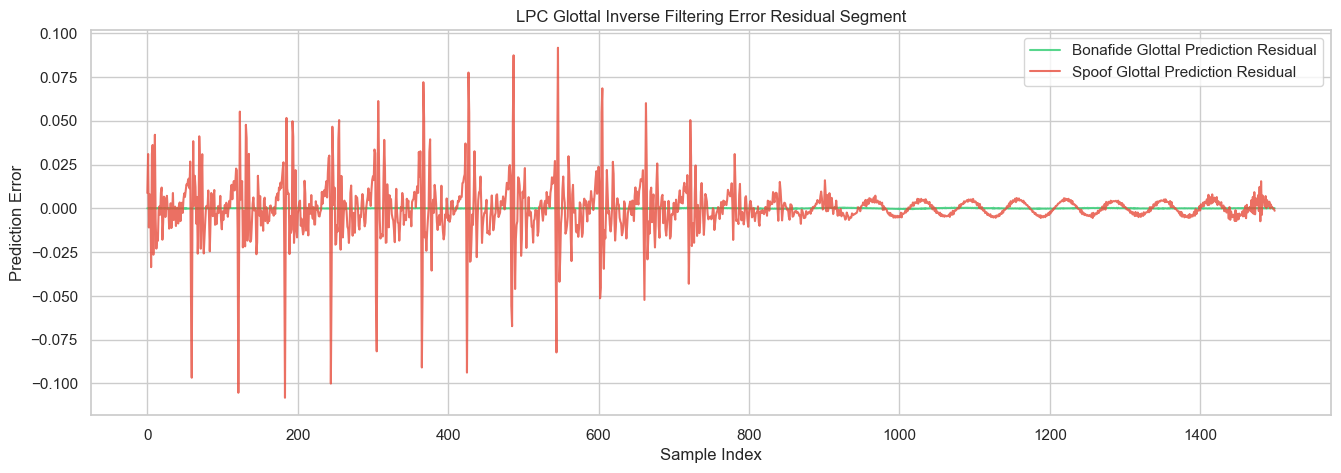

In [6]:
a_b = librosa.lpc(y_b, order=16)
a_s = librosa.lpc(y_s, order=16)

res_b = scipy.signal.lfilter(a_b, [1], y_b)
res_s = scipy.signal.lfilter(a_s, [1], y_s)

plt.figure(figsize=(16, 5))
plt.plot(res_b[2000:3500], label="Bonafide Glottal Prediction Residual", color="#2ecc71", alpha=0.8)
plt.plot(res_s[2000:3500], label="Spoof Glottal Prediction Residual", color="#e74c3c", alpha=0.8)
plt.title("LPC Glottal Inverse Filtering Error Residual Segment")
plt.xlabel("Sample Index")
plt.ylabel("Prediction Error")
plt.legend()
plt.show()